In [1]:
with open("/kaggle/input/datasets/adityajn105/flickr8k/captions.txt", "r") as f:
    captions_raw = f.readlines()


print("Total lines:", len(captions_raw))


for line in captions_raw[:5]:
    print(line.strip())

Total lines: 40456
image,caption
1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg,A girl going into a wooden building .
1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playhouse .


In [2]:
import re

def clean_caption(caption):
    caption = caption.lower()
    caption = re.sub(r"[^a-z\s]", "", caption) 
    caption = caption.strip()
    caption = "startseq " + caption + " endseq"
    return caption


captions_dict = {}

for line in captions_raw[1:]:  
    line = line.strip()
    if not line:
        continue
    img_name, caption = line.split(",", 1)  
    cleaned = clean_caption(caption)
    if img_name not in captions_dict:
        captions_dict[img_name] = []
    captions_dict[img_name].append(cleaned)

# Verify
print("Total images:", len(captions_dict))
print("\nSample image:", list(captions_dict.keys())[0])
print("Its captions:")
for c in list(captions_dict.values())[0]:
    print(" ", c)

Total images: 8091

Sample image: 1000268201_693b08cb0e.jpg
Its captions:
  startseq a child in a pink dress is climbing up a set of stairs in an entry way endseq
  startseq a girl going into a wooden building endseq
  startseq a little girl climbing into a wooden playhouse endseq
  startseq a little girl climbing the stairs to her playhouse endseq
  startseq a little girl in a pink dress going into a wooden cabin endseq


In [3]:
from collections import Counter


all_words = []
for captions in captions_dict.values():
    for caption in captions:
        all_words.extend(caption.split())


word_counts = Counter(all_words)
print("Total unique words:", len(word_counts))


vocab = [word for word, count in word_counts.items() if count >= 5]
print("Vocabulary size after filtering:", len(vocab))


word_to_idx = {word: idx+1 for idx, word in enumerate(vocab)}
idx_to_word = {idx+1: word for idx, word in enumerate(vocab)}

vocab_size = len(vocab) + 1  
print("Final vocab size:", vocab_size)


all_captions_flat = [c for caps in captions_dict.values() for c in caps]
max_len = max(len(c.split()) for c in all_captions_flat)
print("Max caption length:", max_len)

Total unique words: 8780
Vocabulary size after filtering: 2986
Final vocab size: 2987
Max caption length: 37


In [4]:
import numpy as np


all_images = list(captions_dict.keys())
print("Total images:", len(all_images))


np.random.seed(42)  
np.random.shuffle(all_images)

split = int(0.9 * len(all_images))
train_images = all_images[:split]
test_images  = all_images[split:]

train_captions = {img: captions_dict[img] for img in train_images}
test_captions  = {img: captions_dict[img] for img in test_images}

print("Train images:", len(train_captions))
print("Test images: ", len(test_captions))

Total images: 8091
Train images: 7281
Test images:  810


In [5]:
import numpy as np
import os
import pickle
from tqdm import tqdm
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model


base_model = InceptionV3(weights='imagenet')
cnn_model = Model(inputs=base_model.input, outputs=base_model.layers[-2].output)
print("InceptionV3 loaded. Output shape:", cnn_model.output_shape)


img_dir = "/kaggle/input/datasets/adityajn105/flickr8k/Images"

features = {}
all_img_names = list(captions_dict.keys())

for img_name in tqdm(all_img_names, desc="Extracting features"):
    img_path = os.path.join(img_dir, img_name)
    try:
        img = load_img(img_path, target_size=(299, 299))
        img = img_to_array(img)
        img = preprocess_input(img)
        img = np.expand_dims(img, axis=0)
        feature = cnn_model.predict(img, verbose=0)
        features[img_name] = feature
    except Exception as e:
        print(f"Skipped {img_name}: {e}")

print("Done! Total features extracted:", len(features))


pickle.dump(features, open("features.pkl", "wb"))
print("Features saved to features.pkl")

2026-04-22 17:34:21.858325: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776879262.249841      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776879262.364455      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776879263.364154      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776879263.364191      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776879263.364194      23 computation_placer.cc:177] computation placer alr

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
InceptionV3 loaded. Output shape: (None, 2048)


Extracting features:   0%|          | 0/8091 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1776879311.183930      70 service.cc:152] XLA service 0x7f6318053a70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776879311.183985      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776879311.183991      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776879312.497971      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776879318.208949      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
Extracting features: 100%|██████████| 8091/8091 [14:44<00:00,  9.15it/s]


Done! Total features extracted: 8091
Features saved to features.pkl


In [6]:
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Add, Reshape
from tensorflow.keras.models import Model

def build_model(vocab_size, max_len):
    # Input 1: Image feature
    img_input   = Input(shape=(2048,), name="image_input")
    img_dense   = Dense(256, activation='relu')(img_input)
    img_drop    = Dropout(0.3)(img_dense)
    img_reshape = Reshape((1, 256))(img_drop)

    # Input 2: Partial caption sequence
    seq_input = Input(shape=(max_len,), name="seq_input")
    seq_embed = Embedding(vocab_size, 256, mask_zero=True)(seq_input)
    seq_drop  = Dropout(0.3)(seq_embed)
    seq_lstm  = LSTM(256, return_sequences=True, use_cudnn=False)(seq_drop)  # ← fixed

    # Merge
    merged   = Add()([img_reshape, seq_lstm])
    lstm_out = LSTM(256, use_cudnn=False)(merged)  # ← fixed
    output   = Dense(vocab_size, activation='softmax')(lstm_out)

    model = Model(inputs=[img_input, seq_input], outputs=output)
    model.compile(loss='categorical_crossentropy', optimizer='adam')
    return model

model = build_model(vocab_size, max_len)
print("Model rebuilt successfully!")

Model rebuilt successfully!


In [7]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

def data_generator(captions_dict, features, word_to_idx, max_len, vocab_size, batch_size=64):
    img_names = list(captions_dict.keys())
    while True:
        X1, X2, y = [], [], []
        for img_name in img_names:
            feature = features[img_name][0]
            for caption in captions_dict[img_name]:
                seq = [word_to_idx.get(w, 0) for w in caption.split()]
                for i in range(1, len(seq)):
                    in_seq  = pad_sequences([seq[:i]], maxlen=max_len)[0]
                    out_word = to_categorical([seq[i]], num_classes=vocab_size)[0]
                    X1.append(feature)
                    X2.append(in_seq)
                    y.append(out_word)
                    if len(X1) == batch_size:
                        yield [np.array(X1), np.array(X2)], np.array(y)
                        X1, X2, y = [], [], []


total_samples = sum(
    len(caption) - 1
    for caps in train_captions.values()
    for caption in caps
)
steps = total_samples // 64
print("Total training samples:", total_samples)
print("Steps per epoch:", steps)

Total training samples: 2483974
Steps per epoch: 38812


In [8]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

BATCH_SIZE = 64
STEPS_PER_EPOCH = 4000  

def data_generator_flat(captions_dict, features, word_to_idx, max_len, vocab_size):
    img_names = list(captions_dict.keys())
    while True:
        for img_name in img_names:
            feature = features[img_name][0]
            for caption in captions_dict[img_name]:
                seq = [word_to_idx.get(w, 0) for w in caption.split()]
                for i in range(1, len(seq)):
                    in_seq   = pad_sequences([seq[:i]], maxlen=max_len)[0]
                    out_word = to_categorical([seq[i]], num_classes=vocab_size)[0]
                    yield (feature, in_seq), out_word


dataset = tf.data.Dataset.from_generator(
    lambda: data_generator_flat(train_captions, features, word_to_idx, max_len, vocab_size),
    output_signature=(
        (
            tf.TensorSpec(shape=(2048,), dtype=tf.float32),
            tf.TensorSpec(shape=(max_len,), dtype=tf.int32)
        ),
        tf.TensorSpec(shape=(vocab_size,), dtype=tf.float32)
    )
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

callbacks = [
    ModelCheckpoint("best_model.keras", save_best_only=True, verbose=1),
    EarlyStopping(patience=3, verbose=1)
]

history = model.fit(
    dataset,
    epochs=20,
    
    steps_per_epoch=STEPS_PER_EPOCH,
    callbacks=callbacks,
    verbose=1
)

print("Training complete!")

Epoch 1/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 121s 29ms/step - loss: 4.5676
Epoch 2/20


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


4000/4000 ━━━━━━━━━━━━━━━━━━━━ 114s 29ms/step - loss: 3.4351
Epoch 3/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 114s 29ms/step - loss: 3.1816
Epoch 4/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 115s 29ms/step - loss: 3.0386
Epoch 5/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 115s 29ms/step - loss: 2.9400
Epoch 6/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 115s 29ms/step - loss: 2.8460
Epoch 7/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 115s 29ms/step - loss: 2.7999
Epoch 8/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 115s 29ms/step - loss: 2.7527
Epoch 9/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 116s 29ms/step - loss: 2.6935
Epoch 10/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 115s 29ms/step - loss: 2.6491
Epoch 11/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 115s 29ms/step - loss: 2.6131
Epoch 12/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 115s 29ms/step - loss: 2.5830
Epoch 13/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 115s 29ms/step - loss: 2.5371
Epoch 14/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 115s 29ms/step - loss: 2.5119
Epoch 15/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 115s 29ms/step - loss: 2.47

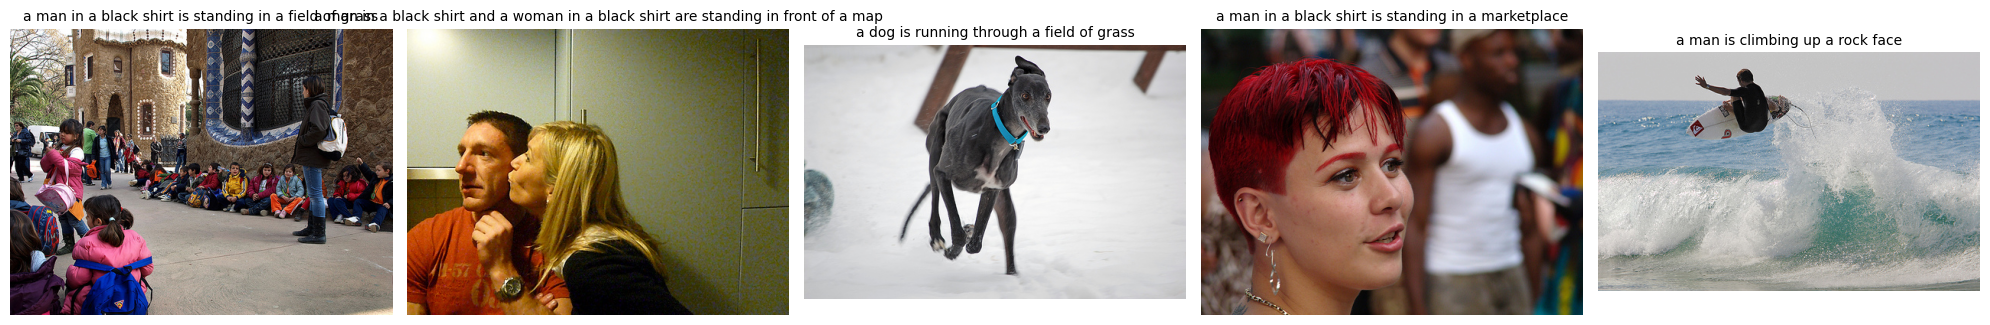

Done!


In [9]:
def generate_caption(model, feature, word_to_idx, idx_to_word, max_len):
    caption = "startseq"
    for _ in range(max_len):
        seq  = [word_to_idx.get(w, 0) for w in caption.split()]
        seq  = pad_sequences([seq], maxlen=max_len)
        pred = model.predict([feature, seq], verbose=0)
        next_idx  = np.argmax(pred)
        next_word = idx_to_word.get(next_idx, "")
        if next_word == "endseq" or not next_word:
            break
        caption += " " + next_word
    return caption.replace("startseq", "").strip()


import matplotlib.pyplot as plt
from PIL import Image

img_dir = "/kaggle/input/datasets/adityajn105/flickr8k/Images"
sample_images = list(test_captions.keys())[:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, img_name in enumerate(sample_images):
    feature = features[img_name]
    caption = generate_caption(model, feature, word_to_idx, idx_to_word, max_len)
    
    img = Image.open(f"{img_dir}/{img_name}")
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(caption, fontsize=10, wrap=True)

plt.tight_layout()
plt.savefig("captions_output.png")
plt.show()
print("Done!")